In [84]:
import jax.numpy as jnp
import jax 
import matplotlib.pyplot as plt
import time

In [85]:
inicio = time.time()
N = 101
M = 51

ti = 0.0
tf = 0.5
t = jnp.linspace(ti,tf,M)

xi = -1.0
xf = 1.0
x = jnp.linspace(xi,xf,N) 

dt = t[1] - t[0] 
dx = (xf - xi)/(N-1)
h = dt/dx

cond = 0


In [86]:
def condicao_inicial(x,index):
    match index: 
        case 0: #suave
            return (jnp.sin(jnp.pi*x))**4
        
        case 1: #discontinua
            return  jnp.where((x >= 1) & (x <= 2), 1.0, 0.0)
        
def solucao_exata(x,u,t_val,index):
    return condicao_inicial(x - u*t_val, index)
        

def passo(u,t):

    #esquema upwind pra resolver a equação
    u_new = u[1:] *(1 - h*(u[1:] - u[:-1]))
    
    u = u.at[1:].set(u_new)

    u = u.at[0].set(u[-1])


    return u, u

u0 = jnp.zeros(N)
u0 = u0.at[:].set(condicao_inicial(x,cond))


passo_compilado = jax.jit(passo)

solucao , historico = jax.lax.scan(passo_compilado,u0,t)
fim = time.time()

print("Tempo total de execução {}".format(fim-inicio))

Tempo total de execução 0.05943417549133301


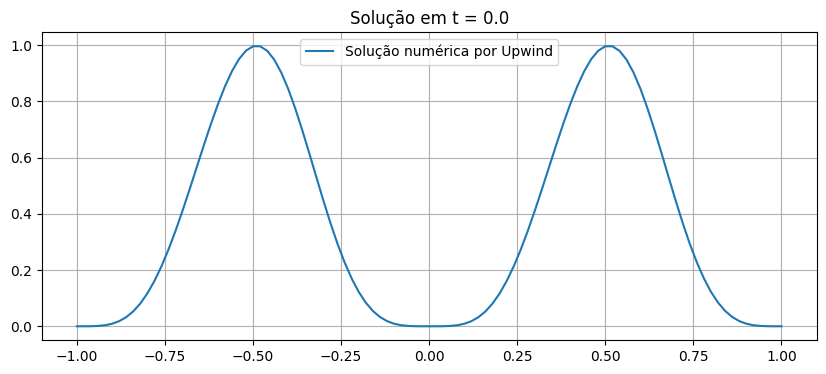

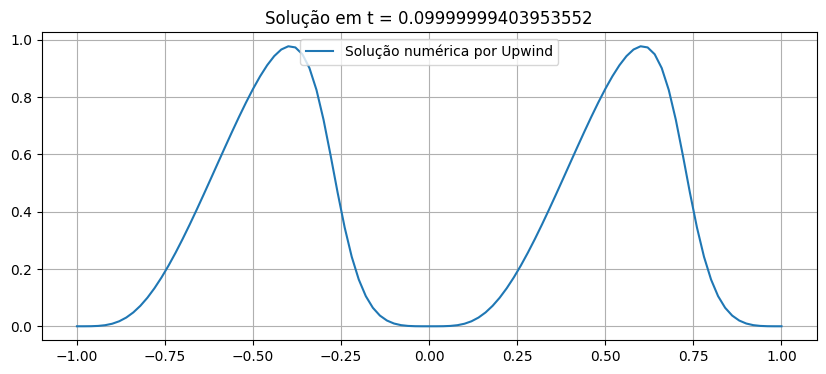

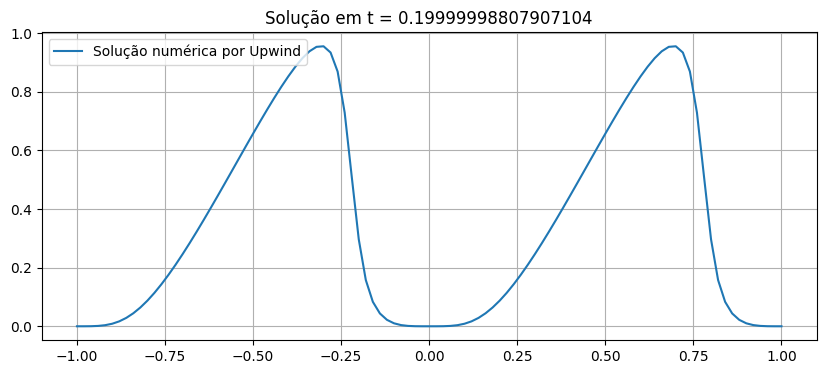

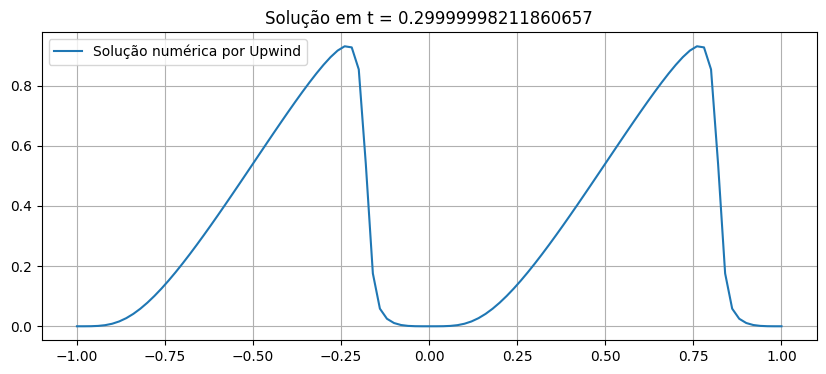

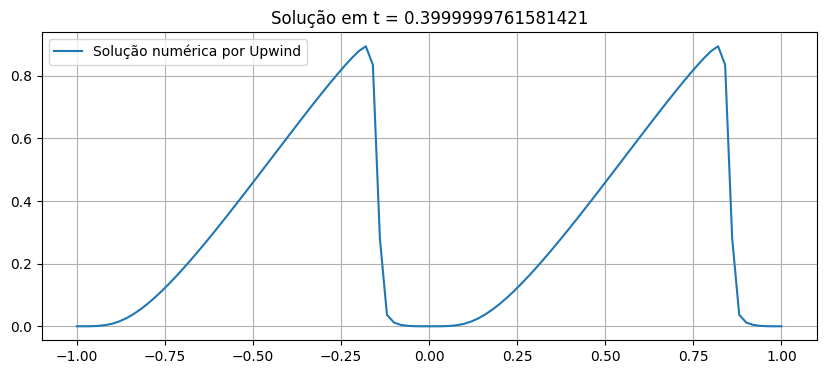

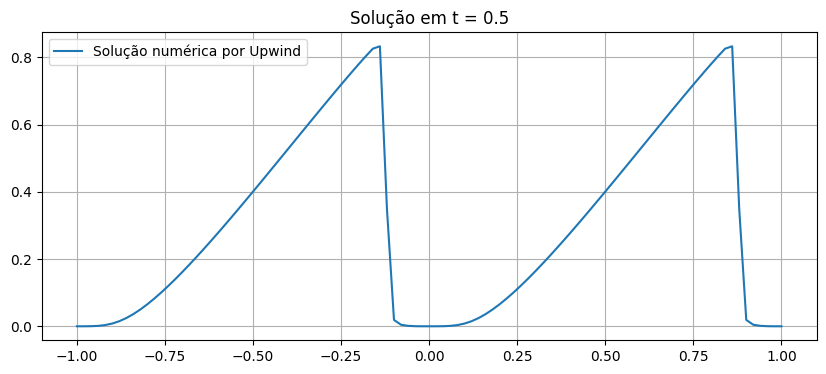

In [87]:

for i in range(M):
    if i%10 == 0:
        plt.figure(figsize=(10,4))
        plt.plot(x,historico[i],label = 'Solução numérica por Upwind')
        # plt.plot(x,solucao_exata(x,historico[i],t[i],cond), label = 'Solução exata', linestyle ='--')
        plt.title("Solução em t = {}".format(t[i]))
        plt.grid(True)
        plt.legend()
        plt.show()